In [1]:
from pathlib import Path


from aereo.backends import LocalProcessBackend
from aereo.client import AereoClient
from aereo.pipeline import ExtractionJob

client = AereoClient()
job = ExtractionJob.load_from_config(
    config_dir=(Path(".").parent / "config").resolve(),
    config_name="job_tessera.yaml",
)

In [2]:
# Search
search_results = client.search(job.search)
print(f"✓ Found {len(search_results)} scenes")

2026-06-17 16:08:08 [info     ] search_called                  provider=SearchTessera
✓ Found 12 scenes


In [3]:
# Prepare
print("\n📦 Preparing tasks...")
tasks = client.prepare_tasks(
    search_results=search_results,
    job=job,
    cells_per_task=2,
)
print(f"✓ Prepared {len(tasks)} tasks")


📦 Preparing tasks...
✓ Prepared 5 tasks


In [4]:
# Extract
print("\n⛏️ Extracting...")
backend = LocalProcessBackend(max_workers=5)
artifacts = client.execute_tasks(tasks, backend=backend)
print(f"✓ Extracted {len(artifacts)} artifacts")


⛏️ Extracting...
2026-06-17 16:08:08 [info     ] execute_tasks_start            backend=LocalProcessBackend failure_mode=strict task_count=5
✓ Extracted 10 artifacts


(<Figure size 2000x1495.93 with 1 Axes>,
 <Axes: title={'center': 'Extracted Patches Spatial Overview'}, xlabel='UTM X', ylabel='UTM Y'>)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


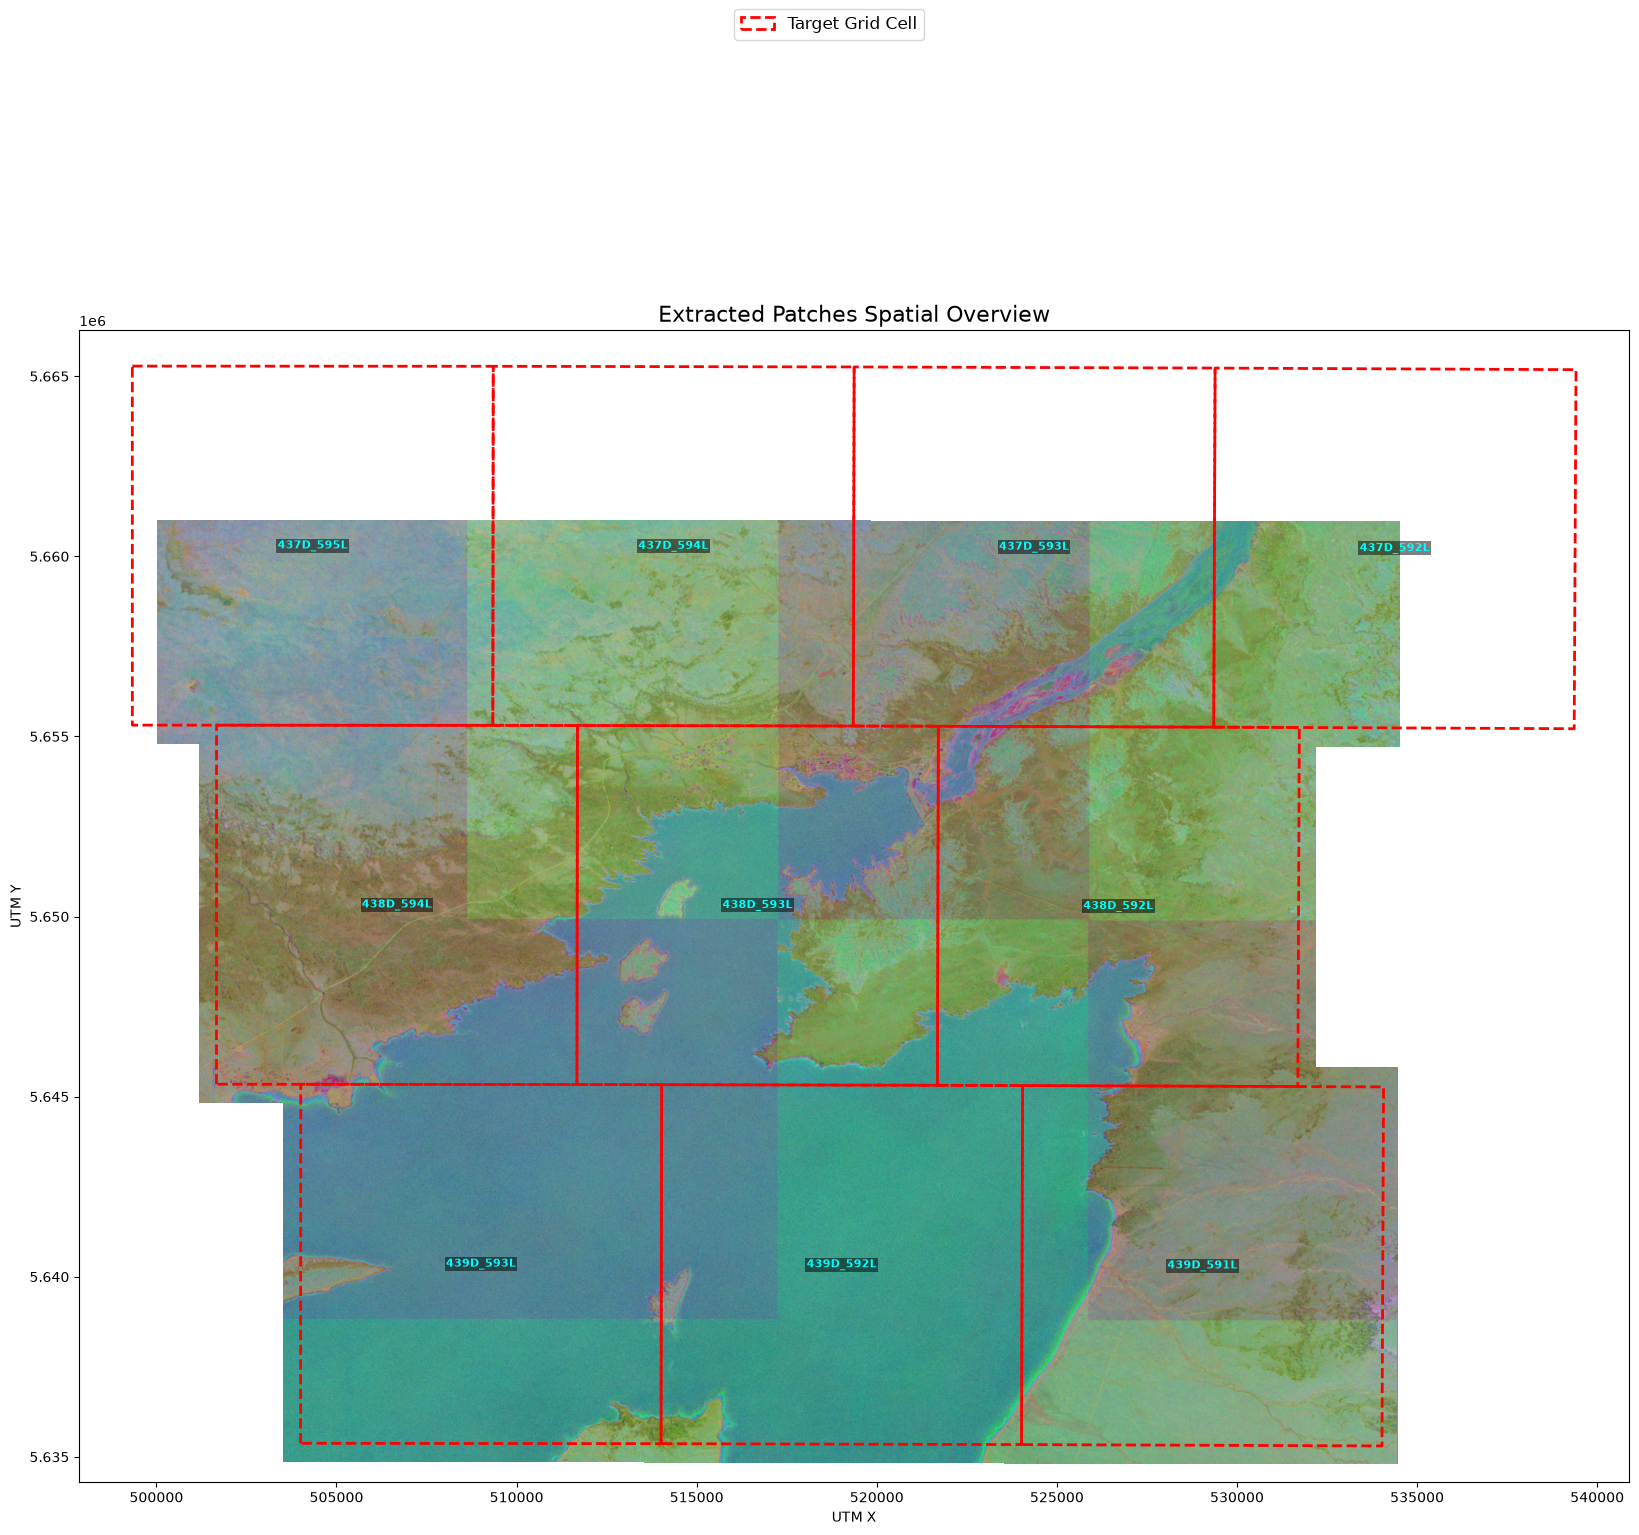

In [ ]:
from aereo.viz import plot_artifact_patches

plot_artifact_patches(artifacts, bands=[1, 2, 3], ds_factor=1, stretch="percentile")